# Quaver Backtest Example

This notebook demonstrates **quaver**'s backtesting capabilities using real stock data from Yahoo Finance.

We will:
1. Discover available strategies via the `StrategyRegistry`
2. Download OHLCV data with `yfinance`
3. Run single-asset backtests (Mean Reversion, VSA Stopping Volume)
4. Visualise equity curves and analyse trades
5. Compare strategy metrics side-by-side
6. Run a multi-asset pairs backtest (AAPL vs MSFT)

## 1. Imports & Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# quaver imports
from quaver.strategies.registry import StrategyRegistry
import quaver.strategies  # noqa: F401 -- triggers auto-registration of all built-in engines
from quaver.backtest import run_backtest, run_multi_asset_backtest

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

## 2. Discover Available Strategies

In [2]:
print("Registered engines:", StrategyRegistry.list_engines())

for name in StrategyRegistry.list_engines():
    cls = StrategyRegistry.get(name)
    kind = StrategyRegistry.get_strategy_kind(name)
    defaults = cls.get_default_parameters()
    print(f"\n--- {name} ({kind}) ---")
    print(f"  Display name: {cls.display_name}")
    print(f"  Description:  {cls.description}")
    print(f"  Defaults:     {defaults}")

Registered engines: ['breakout_consolidation', 'mean_reversion', 'pairs_mean_reversion', 'pullback_trend', 'regime_mean_reversion', 'reversal_support', 'vsa_stopping_volume']

--- breakout_consolidation (single) ---
  Display name: Breakout from Consolidation
  Description:  Detects low-volatility consolidation phases and generates BUY signals when price breaks above the range ceiling with above-average volume and declining ATR, in the direction of the prevailing trend.
  Defaults:     {'ma_period': 50, 'consolidation_period': 20, 'range_max_pct': 0.1, 'atr_period': 14, 'atr_lookback': 10, 'volume_sma_period': 20}

--- mean_reversion (single) ---
  Display name: Mean Reversion
  Description:  Dual moving-average mean reversion. BUY when fast MA is below slow MA by more than threshold (oversold). SELL when above (overbought).
  Defaults:     {'fast_period': 20, 'slow_period': 50, 'threshold': 0.02}

--- pairs_mean_reversion (multi) ---
  Display name: Pairs Mean Reversion
  Description:

## 3. Download Stock Data

yfinance returns columns like `Open, High, Low, Close, Volume` (capitalised).  
quaver expects `ts, open, high, low, close, volume` (lowercase).  
We define a helper to convert.

In [3]:
def yf_to_quaver(ticker: str, period: str = "2y", interval: str = "1d") -> pd.DataFrame:
    """Download OHLCV data from yfinance and format it for quaver."""
    df = yf.download(ticker, period=period, interval=interval, progress=False)
    # Flatten multi-level columns if present (single ticker)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.rename(columns=str.lower)
    df = df.reset_index()
    # Rename the date/datetime index column to 'ts'
    date_col = [c for c in df.columns if c.lower() in ("date", "datetime")][0]
    df = df.rename(columns={date_col: "ts"})
    return df[["ts", "open", "high", "low", "close", "volume"]]

In [4]:
aapl = yf_to_quaver("AAPL")
print(f"AAPL: {len(aapl)} rows, {aapl['ts'].min()} to {aapl['ts'].max()}")
aapl.tail()

AAPL: 501 rows, 2024-03-07 00:00:00 to 2026-03-06 00:00:00


Price,ts,open,high,low,close,volume
496,2026-03-02,262.410004,266.529999,260.200012,264.720001,41827900
497,2026-03-03,263.480011,265.559998,260.130005,263.750000,38568900
498,2026-03-04,264.649994,266.149994,261.420013,262.519989,39803100
499,2026-03-05,260.790009,261.559998,257.250000,260.290009,49658600
500,2026-03-06,258.630005,258.769989,254.369995,257.459991,41094000


## 4. Strategy 1 -- Mean Reversion Backtest

In [5]:
mr_defaults = StrategyRegistry.get("mean_reversion").get_default_parameters()
print("Mean Reversion defaults:", mr_defaults)

mr_result = run_backtest(
    engine_name="mean_reversion",
    parameters=mr_defaults,
    candles=aapl,
    instrument_id="AAPL",
    initial_capital=10_000,
    quantity_per_trade=10,
)

print(f"\nTotal trades: {mr_result.total_trades}")
mr_result.summary()

Mean Reversion defaults: {'fast_period': 20, 'slow_period': 50, 'threshold': 0.02}

Total trades: 2


{'instrument_id': 'AAPL',
 'initial_capital': 10000,
 'final_cash': 9965.01,
 'total_return_pct': -0.35,
 'total_trades': 2,
 'winning_trades': 1,
 'losing_trades': 1,
 'win_rate_pct': 50.0,
 'avg_pnl': -17.4929,
 'profit_factor': 0.7416,
 'sharpe_ratio': -1.6653,
 'max_drawdown_pct': -1.35}

## 5. Visualise Equity Curve

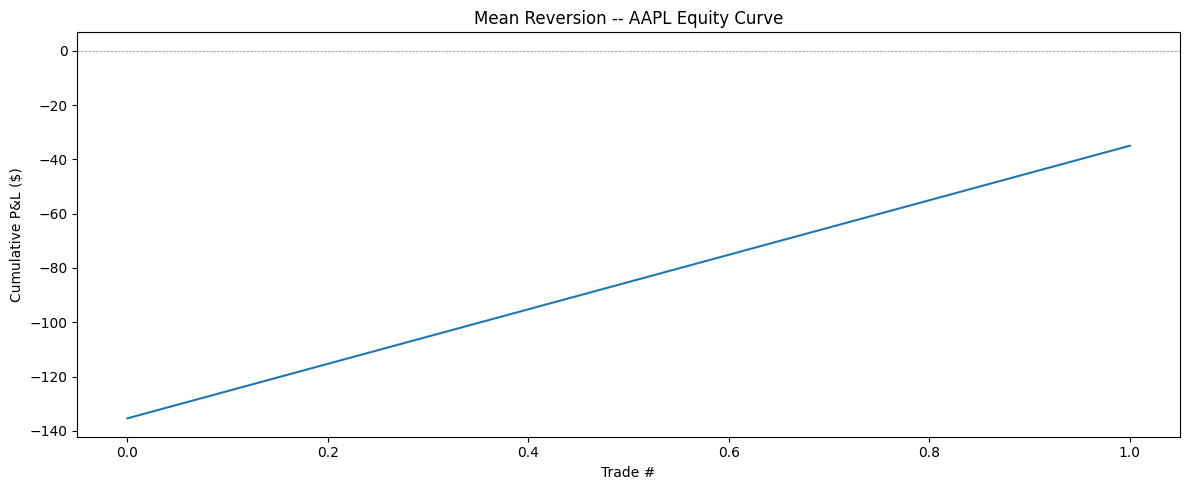

In [6]:
fig, ax = plt.subplots()
cpnl = mr_result.cumulative_pnl
ax.plot(range(len(cpnl)), cpnl, linewidth=1.5)
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.set_xlabel("Trade #")
ax.set_ylabel("Cumulative P&L ($)")
ax.set_title("Mean Reversion -- AAPL Equity Curve")
plt.tight_layout()
plt.show()

## 6. Trade Analysis

In [7]:
trades_df = pd.DataFrame(
    [
        {
            "entry_ts": t.entry_ts,
            "exit_ts": t.exit_ts,
            "direction": t.direction.value,
            "entry_price": round(t.entry_price, 2),
            "exit_price": round(t.exit_price, 2),
            "quantity": t.quantity,
            "pnl": round(t.pnl, 2),
        }
        for t in mr_result.trades
    ]
)
trades_df

,entry_ts,exit_ts,direction,entry_price,exit_price,quantity,pnl
0,2025-02-03,2025-07-25,buy,226.77,213.23,10,-135.40
1,2026-01-21,2026-03-06,buy,247.42,257.46,10,100.42


## 7. Strategy 2 -- VSA Stopping Volume

Run with `allow_shorting=True` so SELL signals can open short positions.

In [ ]:
vsa_defaults = StrategyRegistry.get("vsa_stopping_volume").get_default_parameters()
print("VSA defaults:", vsa_defaults)

# Relax stopping_vol_rel and spread_small for this demo dataset --
# AAPL daily bars rarely hit the very strict defaults.
vsa_params = {**vsa_defaults, "stopping_vol_rel": 1.3, "spread_small": 0.9}
print("VSA params (adjusted):", vsa_params)

vsa_result = run_backtest(
    engine_name="vsa_stopping_volume",
    parameters=vsa_params,
    candles=aapl,
    instrument_id="AAPL",
    initial_capital=10_000,
    quantity_per_trade=10,
    allow_shorting=True,
)

print(f"\nTotal trades: {vsa_result.total_trades}")
vsa_result.summary()

## 8. Strategy Comparison

In [ ]:
comparison = pd.DataFrame(
    {
        "Mean Reversion": mr_result.summary(),
        "VSA Stopping Volume": vsa_result.summary(),
    }
).T
comparison

## 9. Strategy 3 -- Pairs Mean Reversion (Multi-Asset)

This strategy trades the normalised price spread between AAPL and MSFT.

In [ ]:
msft = yf_to_quaver("MSFT")
print(f"MSFT: {len(msft)} rows, {msft['ts'].min()} to {msft['ts'].max()}")
msft.tail()

In [ ]:
pairs_defaults = StrategyRegistry.get("pairs_mean_reversion").get_default_parameters()
pairs_params = {
    **pairs_defaults,
    "instrument_a": "AAPL",
    "instrument_b": "MSFT",
}
print("Pairs params:", pairs_params)

pairs_results = run_multi_asset_backtest(
    engine_name="pairs_mean_reversion",
    parameters=pairs_params,
    candles_map={"AAPL": aapl, "MSFT": msft},
    initial_capital=10_000,
    quantity_per_trade=10,
    allow_shorting=True,
)

for inst_id, result in pairs_results.items():
    print(f"\n=== {inst_id} ===")
    for k, v in result.summary().items():
        print(f"  {k}: {v}")

## 10. Pairs Spread Visualisation

In [ ]:
# Align the two price series on overlapping dates
merged = pd.merge(
    aapl[["ts", "close"]].rename(columns={"close": "aapl_close"}),
    msft[["ts", "close"]].rename(columns={"close": "msft_close"}),
    on="ts",
)

merged["spread"] = merged["aapl_close"] - merged["msft_close"]

window = pairs_params["spread_window"]
merged["spread_mean"] = merged["spread"].rolling(window).mean()
merged["spread_std"] = merged["spread"].rolling(window).std(ddof=1)
merged["z_score"] = (merged["spread"] - merged["spread_mean"]) / merged["spread_std"]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Spread
axes[0].plot(merged["ts"], merged["spread"], label="Spread (AAPL - MSFT)", linewidth=1)
axes[0].plot(
    merged["ts"],
    merged["spread_mean"],
    label=f"Rolling mean ({window}d)",
    linewidth=1,
    linestyle="--",
)
axes[0].set_ylabel("Price Spread ($)")
axes[0].set_title("AAPL - MSFT Price Spread")
axes[0].legend()

# Z-score
axes[1].plot(merged["ts"], merged["z_score"], linewidth=1, color="tab:orange")
axes[1].axhline(
    pairs_params["entry_z"],
    color="red",
    linestyle="--",
    linewidth=0.8,
    label=f"Entry z = +/- {pairs_params['entry_z']}",
)
axes[1].axhline(-pairs_params["entry_z"], color="red", linestyle="--", linewidth=0.8)
axes[1].axhline(
    pairs_params["exit_z"],
    color="green",
    linestyle=":",
    linewidth=0.8,
    label=f"Exit z = +/- {pairs_params['exit_z']}",
)
axes[1].axhline(-pairs_params["exit_z"], color="green", linestyle=":", linewidth=0.8)
axes[1].axhline(0, color="grey", linewidth=0.5)
axes[1].set_ylabel("Z-Score")
axes[1].set_xlabel("Date")
axes[1].set_title("Spread Z-Score")
axes[1].legend()

plt.tight_layout()
plt.show()

## Summary

In this notebook we demonstrated the core quaver workflow:

- **Strategy discovery** via `StrategyRegistry.list_engines()` and `get_default_parameters()`
- **Single-asset backtesting** with `run_backtest()` for Mean Reversion and VSA Stopping Volume
- **Equity curve visualisation** using the `cumulative_pnl` property
- **Trade-level analysis** by converting `TradeRecord` objects to a DataFrame
- **Strategy comparison** via side-by-side `summary()` metrics
- **Multi-asset backtesting** with `run_multi_asset_backtest()` for Pairs Mean Reversion
- **Spread and z-score visualisation** showing the statistical arbitrage dynamics

All strategies use walk-forward evaluation with no look-ahead bias.